In [1]:
import pandas as pd

In [6]:
products = pd.read_csv("../data/E-Commerce Dataset/products_dataset.csv")
orders = pd.read_csv("../data/E-Commerce Dataset/order_items_dataset.csv")
product_category = pd.read_csv("../data/E-Commerce Dataset/product_category_name_translation.csv")
order_reviews = pd.read_csv("../data_cleaning/processed_customer_reviews.csv")

In [8]:
print("Productss table:", products.columns)
print("Orders table:", orders.columns)
print("Product Category:", product_category.columns)
print("Order Reviews:", order_reviews.columns)

Productss table: Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')
Orders table: Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')
Product Category: Index(['product_category_name', 'product_category_name_english'], dtype='str')
Order Reviews: Index(['Unnamed: 0', 'order_id', 'review_id', 'review_comment_title_en',
       'review_comment_message_en', 'review_text_combined', 'sentiment',
       'sentiment_score', 'primary_topic', 'topics', 'classification_reason'],
      dtype='str')


In [9]:
# Orders + Products
df = orders.merge(
    products,
    on='product_id',
    how='left'
)

# Add English category
df = df.merge(
    product_category,
    on='product_category_name',
    how='left'
)

# Add reviews
df = df.merge(
    order_reviews[['order_id', 'sentiment', 'sentiment_score',
                   'primary_topic', 'topics', 'classification_reason']],
    on='order_id',
    how='left'
)

In [19]:
df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,sentiment,sentiment_score,primary_topic,topics,classification_reason
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,650.0,28.0,9.0,14.0,cool_stuff,Positive,0.700,Positive Experience,Positive Experience,Positive sentiment; mentions 'perfect' related...
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,30000.0,50.0,30.0,40.0,pet_shop,NaN,NaN,NaN,NaN,NaN
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,3050.0,33.0,13.0,33.0,furniture_decor,Positive,0.636,Delivery Speed,"Delivery Speed, Product Quality",Positive sentiment; mentions 'arrived ahead' r...
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,200.0,16.0,10.0,15.0,perfumery,NaN,NaN,NaN,NaN,NaN
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,3750.0,35.0,40.0,30.0,garden_tools,Positive,0.421,Delivery Speed,"Delivery Speed, Positive Experience",Positive sentiment; mentions 'on time' related...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112822,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,...,10150.0,89.0,15.0,40.0,housewares,NaN,NaN,NaN,NaN,NaN
112823,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,...,8950.0,45.0,26.0,38.0,computers_accessories,NaN,NaN,NaN,NaN,NaN
112824,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,...,967.0,21.0,24.0,19.0,sports_leisure,NaN,NaN,NaN,NaN,NaN
112825,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,...,100.0,20.0,20.0,20.0,computers_accessories,Neutral,0.000,Other,Other,Neutral tone detected in review text; no speci...


In [10]:
df['primary_topic'].value_counts(dropna=False)

primary_topic
NaN                         63303
Positive Experience         16538
Other                       15181
Delivery Delay               4605
Delivery Speed               3240
Product Quality              2723
Product Condition/Damage     1363
Shipping/Logistics           1301
Return/Refund                1193
Price/Value                   909
Packaging                     766
Product Description           740
Seller Service                358
Size/Fit                      277
Product Functionality         270
Customer Service               60
Name: count, dtype: int64

In [11]:
df['topics'].value_counts(dropna=False).head(20)

topics
NaN                                                     63303
Other                                                   15181
Positive Experience                                     13755
Delivery Delay                                           3515
Product Quality, Positive Experience                     2487
Delivery Speed, Positive Experience                      1697
Delivery Speed                                           1316
Product Quality                                          1201
Shipping/Logistics                                       1113
Return/Refund                                             886
Product Condition/Damage                                  568
Delivery Speed, Product Quality, Positive Experience      465
Packaging                                                 423
Price/Value, Positive Experience                          413
Price/Value                                               412
Packaging, Positive Experience                            360
P

In [21]:
quality_df = df[
    df['primary_topic'].str.contains(
        'product quality', case=False, na=False
    )
]

In [22]:
quality_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,sentiment,sentiment_score,primary_topic,topics,classification_reason
19,000e562887b1f2006d75e0be9558292e,1,5ed9eaf534f6936b51d0b6c5e4d5c2e9,8cbac7e12637ed9cffa18c7875207478,2018-02-28 12:08:37,25.00,16.11,cool_stuff,51.0,693.0,...,600.0,20.0,20.0,21.0,cool_stuff,Positive,0.440,Product Quality,Product Quality,Positive sentiment; mentions 'good product' re...
95,0035246a40f520710769010f752e7507,1,8a6187b2665118d5095f99a25fd7ba7a,4a3ca9315b744ce9f8e9374361493884,2017-08-23 01:25:39,87.00,12.11,cama_mesa_banho,56.0,275.0,...,1300.0,45.0,15.0,35.0,bed_bath_table,Positive,0.771,Product Quality,"Product Quality, Positive Experience",Positive sentiment; mentions 'quality' related...
187,0079bca8e89bd52fdb87408e4f3fb94d,1,19421075ae0b585f2dc13ff149e2119d,4c2b230173bb36f9b240f2b8ac11786e,2018-05-10 03:31:09,49.90,7.39,esporte_lazer,32.0,1797.0,...,150.0,16.0,16.0,11.0,sports_leisure,Positive,0.717,Product Quality,"Product Quality, Positive Experience",Positive sentiment; mentions 'good product' re...
259,00a9536682ecb394a3794c1608200803,1,24a014458ccc6e989b4fcef5fa71da58,4a3ca9315b744ce9f8e9374361493884,2017-05-18 23:50:08,109.90,12.27,cama_mesa_banho,53.0,348.0,...,2000.0,45.0,15.0,35.0,bed_bath_table,Neutral,0.000,Product Quality,Product Quality,Neutral sentiment; mentions 'quality' related ...
272,00af53fdc2002f5b6a8f16db648e003b,1,c6336fa91fbd87c359e44f5dca5a90ed,4c2b230173bb36f9b240f2b8ac11786e,2017-06-26 15:15:17,39.90,11.85,esporte_lazer,39.0,772.0,...,150.0,16.0,16.0,11.0,sports_leisure,Positive,0.440,Product Quality,Product Quality,Positive sentiment; mentions 'good product' re...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112631,ff8ac98b246381dba3eb9d51e77faf6c,1,7e0dc102074f8285580c9777f79c90cf,e26901d5ab434ce92fd9b5c256820a4e,2017-03-17 15:15:06,39.90,10.96,ferramentas_jardim,60.0,1251.0,...,800.0,30.0,10.0,30.0,garden_tools,Positive,0.660,Product Quality,"Product Quality, Positive Experience",Positive sentiment; mentions 'good product' re...
112643,ff92b9f4c3333e0e977c4530a2e8d9cb,1,2b4609f8948be18874494203496bc318,cc419e0650a3c5ba77189a1882b7556a,2018-06-19 11:01:05,79.99,18.66,beleza_saude,59.0,492.0,...,250.0,22.0,10.0,18.0,health_beauty,Positive,0.572,Product Quality,"Product Quality, Positive Experience",Positive sentiment; mentions 'quality' related...
112655,ff98857a36b901baaa0dc19c6fcf65fe,1,f59871b3d9da4c64cbe41ad3dd04dc14,116ccb1a1604bc88e4d234a8c23f33de,2017-11-23 20:31:16,12.70,15.11,artigos_de_natal,60.0,565.0,...,400.0,17.0,21.0,11.0,christmas_supplies,Positive,0.177,Product Quality,Product Quality,Positive sentiment; mentions 'quality' related...
112656,ff98857a36b901baaa0dc19c6fcf65fe,2,f59871b3d9da4c64cbe41ad3dd04dc14,116ccb1a1604bc88e4d234a8c23f33de,2017-11-23 20:31:16,12.70,15.11,artigos_de_natal,60.0,565.0,...,400.0,17.0,21.0,11.0,christmas_supplies,Positive,0.177,Product Quality,Product Quality,Positive sentiment; mentions 'quality' related...


In [28]:
category_quality = (
    df.groupby('product_category_name_english')
      .agg(
          total_orders=('order_id', 'nunique'),
          quality_issues=('order_id',
                          lambda x: x.isin(quality_df['order_id']).sum())
      )
)

category_quality['quality_issue_rate'] = (
    category_quality['quality_issues'] /
    category_quality['total_orders'] * 100
)

category_quality = category_quality.sort_values(
    'quality_issue_rate',
    ascending=False
)

In [29]:
category_quality_filtered = category_quality[
    category_quality['total_orders'] >= 500
].sort_values(
    'quality_issue_rate',
    ascending=False
)

category_quality_filtered.head(10)

,total_orders,quality_issues,quality_issue_rate
product_category_name_english,,,
office_furniture,1273,162,12.725844
telephony,4199,337,8.025720
bed_bath_table,9417,715,7.592652
home_appliances,764,56,7.329843
fashion_bags_accessories,1864,135,7.242489
luggage_accessories,1034,73,7.059961
furniture_decor,6449,453,7.024345
construction_tools_construction,748,52,6.951872
computers_accessories,6689,453,6.772313


In [43]:
# Quality issues by seller
seller_quality = (
    quality_df.groupby('seller_id')
    .agg(
        quality_issues=('order_id', 'nunique')
    )
    .reset_index()
)

# Total deliveries/orders by seller
seller_deliveries = (
    df.groupby('seller_id')
    .agg(
        total_deliveries=('order_id', 'nunique')
    )
    .reset_index()
)

# Number of categories handled by seller
seller_categories = (
    df.groupby('seller_id')
    .agg(
        number_of_categories=('product_category_name_english', 'nunique')
    )
    .reset_index()
)

# Combine
seller_analysis = (
    seller_quality
    .merge(seller_deliveries, on='seller_id', how='left')
    .merge(seller_categories, on='seller_id', how='left')
)

# Quality issue rate
seller_analysis['quality_issue_rate'] = (
    seller_analysis['quality_issues'] /
    seller_analysis['total_deliveries'] * 100
)

# Sort by highest quality issues
seller_analysis = seller_analysis.sort_values(
    'quality_issue_rate',
    ascending=False
)

seller_analysis[seller_analysis["total_deliveries"]>100].head(20)

# seller_analysis.head(20)

,seller_id,quality_issues,total_deliveries,number_of_categories,quality_issue_rate
238,2eb70248d66e0e3ef83659f71b244378,48,202,11,23.762376
147,1ca7077d890b907f89be8c954a02686a,19,115,2,16.521739
336,44073f8b7e41514de3b7815dd0237f4f,19,144,14,13.194444
541,710e3548e02bc1d2831dfc4f1b5b14d4,17,136,9,12.500000
848,b76dba6c951ab00dc4edf0a1aa88037e,19,159,3,11.949686
130,18a349e75d307f4b4cc646a691ed4216,14,121,17,11.570248
599,7c67e1448b00f6e969d365cea6b010ab,112,982,6,11.405295
893,c33847515fa6305ce6feb1e818569f13,13,114,2,11.403509
534,7040e82f899a04d1b434b795a43b4617,24,212,10,11.320755
422,5656537e588803a555b8eb41f07a944b,19,174,11,10.919540


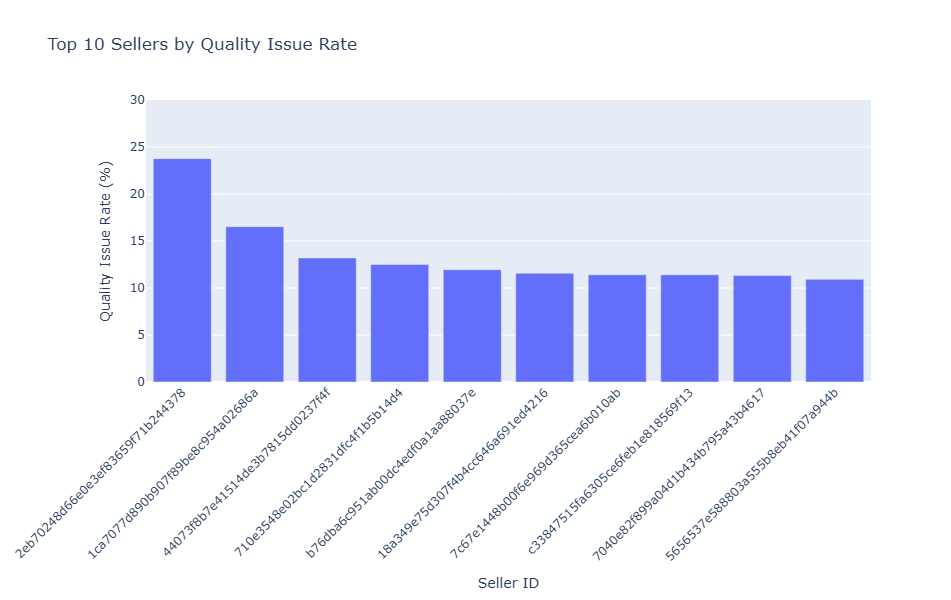

In [64]:
import plotly.express as px

top_10_sellers = (
    seller_analysis[seller_analysis['total_deliveries'] > 100]
    .sort_values('quality_issue_rate', ascending=False)
    .head(10)
)

fig = px.bar(
    top_10_sellers,
    x='seller_id',
    y='quality_issue_rate',
    hover_data=[
        'quality_issues',
        'total_deliveries',
        'number_of_categories'
    ],
    title='Top 10 Sellers by Quality Issue Rate',
    labels={
        'seller_id': 'Seller ID',
        'quality_issue_rate': 'Quality Issue Rate (%)',
        'quality_issues': 'Quality Issues',
        'total_deliveries': 'Total Deliveries',
        'number_of_categories': 'Number of Categories'
    }
)

fig.update_layout(
    height=600,
    xaxis_tickangle=-45,
    yaxis=dict(
        title='Quality Issue Rate (%)',
        tick0=0,
        dtick=5,
        range=[0, 30]
    )
)

fig.show()

In [44]:
product_quality = (
    quality_df.groupby('product_id')
    .agg(
        quality_issues=('order_id', 'nunique')
    )
    .reset_index()
    .sort_values('quality_issues', ascending=False)
)

product_quality.head(20)

,product_id,quality_issues
2445,99a4788cb24856965c36a24e339b6058,37
2214,89b121bee266dcd25688a1ba72eefb61,23
697,2b4609f8948be18874494203496bc318,21
2716,aca2eb7d00ea1a7b8ebd4e68314663af,21
2013,7c1bd920dbdf22470b68bde975dd3ccf,19
868,368c6c730842d78016ad823897a372db,19
331,154e7e31ebfa092203795c972e5804a6,18
1363,53759a2ecddad2bb87a079a1f1519f73,17
3332,d1c427060a0f73f6b889a5c7c61f2ac4,15
908,389d119b48cf3043d311335e499d9c6b,14


In [56]:
product_quality_rate = (
    df.groupby('product_id')
      .agg(
          total_orders=('order_id', 'nunique')
      )
      .reset_index()
)

quality_counts = (
    quality_df.groupby('product_id')
    .agg(
        quality_issues=('order_id', 'nunique')
    )
    .reset_index()
)

product_quality_rate = product_quality_rate.merge(
    quality_counts,
    on='product_id',
    how='left'
)

product_quality_rate['quality_issues'] = (
    product_quality_rate['quality_issues'].fillna(0)
)

product_quality_rate['quality_issue_rate'] = (
    product_quality_rate['quality_issues'] /
    product_quality_rate['total_orders'] * 100
)

product_quality_rate = product_quality_rate.sort_values(
    'total_orders',
    ascending=False
)

product_quality_rate[product_quality_rate["quality_issue_rate"] > 10].sort_values("total_orders", ascending=False)

,product_id,total_orders,quality_issues,quality_issue_rate
27128,d285360f29ac7fd97640bf0baef03de0,122,13.0,10.655738
17175,84f456958365164420cfc80fbe4c7fab,106,14.0,13.207547
23325,b5e13c9a353102f79c6206ff5cb61a50,83,10.0,12.048193
32348,fb55982be901439613a95940feefd9ee,82,13.0,15.853659
10916,5411e9269501a870cabf632f05655131,75,9.0,12.000000
...,...,...,...,...
32833,ff4580bbb95dbae914ec0a9b76b0a5c4,1,1.0,100.000000
80,00bc6e6d4ceb98ec7ed058b0a243a8b9,1,1.0,100.000000
62,00929aaa7751a77220db9caa1ae6d3ab,1,1.0,100.000000
32860,ff7ac89ca5b77d0fb5f8a65262d73956,1,1.0,100.000000
